<a href="https://colab.research.google.com/github/rahulsanjel/Aritificialintelligence/blob/main/2330993_RahulSharma_VisonTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flower Classification using CNNs
**Dataset:** 19 flower types | **Total Images:** -17,231

**Parts Covered:**
- Part A: CNN from Scratch (Baseline + Deeper)
- Part B: Transfer Learning (MobileNetV2)

---

## Mount Google Drive & Install Libraries

In [1]:
# ── Mount Google Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, pickle

# Dataset path
DATA_PATH = '/content/drive/MyDrive/CNN/flowerproject/flowers'

# Create folders for saving models and history
MODELS_DIR  = '/content/drive/MyDrive/CNN/flowerproject/models'
HISTORY_DIR = '/content/drive/MyDrive/CNN/flowerproject/history'
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

print("✅ Drive mounted!")
print(f"   Models  → {MODELS_DIR}")
print(f"   History → {HISTORY_DIR}")

# ── Helper: save / load history ──────────────────────────────────────────────
def save_history(history_obj, name):
    path = f'{HISTORY_DIR}/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(history_obj.history, f)
    print(f"  History saved → {path}")

def load_history(name):
    path = f'{HISTORY_DIR}/{name}.pkl'
    with open(path, 'rb') as f:
        data = pickle.load(f)
    # Wrap in a simple object so plot_curves works
    class H: pass
    h = H(); h.history = data
    return h


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!
   Models  → /content/drive/MyDrive/CNN/flowerproject/models
   History → /content/drive/MyDrive/CNN/flowerproject/history


In [2]:
import shutil, os

LOCAL_DATA = '/content/flowers'

if os.path.exists(LOCAL_DATA):
    print("✅ Dataset already on local disk — skipping copy")
else:
    print("Copying dataset from Drive to local SSD (faster training)...")
    shutil.copytree('/content/drive/MyDrive/CNN/flowers', LOCAL_DATA)
    print("Done! Files copied:", sum(len(f) for _,_,f in os.walk(LOCAL_DATA)))

DATA_PATH = LOCAL_DATA
print(f"DATA_PATH = {DATA_PATH}")


✅ Dataset already on local disk — skipping copy
DATA_PATH = /content/flowers


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

IMG_SIZE   = (128, 128)
BATCH_SIZE = 64
NUM_CLASSES = 19

print("All imports done!")

All imports done!


# Data Understanding, Analysis & Visualization

The dataset contains 17,231 images of 19 different flower classes collected from Kaggle. Some classes have more images than others, so the dataset is slightly imbalanced. For example, iris has over 1000 images while orchid and lavender have fewer images.

The dataset was split into 80% training data and 20% validation data. This allows the model to learn from most images while still testing performance on unseen data.

Before training, all images were resized to 128 × 128 pixels and pixel values were normalized from 0–255 to 0–1 to help the model train faster and more efficiently.

## Data Cleaning
Before training the model we clean the dataset to remove any
corrupted or unreadable image files and images that are too
small to be useful. Corrupted images would cause errors during
training and very small images (under 32x32 pixels) do not
contain enough information for the model to learn from.

This step ensures that all images fed into the model are valid
and of sufficient quality.

In [4]:
# ── Data Cleaning: Remove corrupted and too-small images ────────────────────
from PIL import Image
import os

corrupted_removed = []
too_small_removed = []

print("Scanning dataset for corrupted and too-small images...")

for root, dirs, files in os.walk(DATA_PATH):
    for fname in files:
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        path = os.path.join(root, fname)

        # ── Step 1: Check for corrupted/unreadable images ──
        try:
            img = Image.open(path)
            img.verify()          # verify file integrity
        except Exception:
            corrupted_removed.append(path)
            os.remove(path)
            continue              # skip size check if already removed

        # ── Step 2: Check for too-small images (< 32x32) ──
        try:
            img = Image.open(path)
            w, h = img.size
            if w < 32 or h < 32:
                too_small_removed.append(path)
                os.remove(path)
        except Exception:
            pass

print(f"\n✅ Cleaning complete!")
print(f"   Corrupted images removed : {len(corrupted_removed)}")
print(f"   Too-small images removed : {len(too_small_removed)}")
print(f"   Total removed            : {len(corrupted_removed) + len(too_small_removed)}")

if corrupted_removed:
    print("\nCorrupted files:")
    for p in corrupted_removed: print(f"  {p}")
if too_small_removed:
    print("\nToo-small files:")
    for p in too_small_removed: print(f"  {p}")


Scanning dataset for corrupted and too-small images...

✅ Cleaning complete!
   Corrupted images removed : 0
   Too-small images removed : 0
   Total removed            : 0


In [5]:

# ── Dataset Description ──────────────────────────────────────────────────────
# This dataset has 19 types of flowers.
# We will classify images into one of 19 classes.

# Count images per class
classes = sorted(os.listdir(DATA_PATH))
counts  = [len(os.listdir(os.path.join(DATA_PATH, c))) for c in classes]

print(f"Total classes : {len(classes)}")
print(f"Total images  : {sum(counts)}")
print("\nImages per class:")
for c, n in zip(classes, counts):
    print(f"  {c:<20} {n}")

Total classes : 19
Total images  : 17229

Images per class:
  astilbe              737
  bellflower           873
  black_eyed_susan     1000
  calendula            978
  california_poppy     1022
  carnation            923
  common_daisy         980
  coreopsis            1047
  daffodil             970
  dandelion            1052
  iris                 1054
  lavender             500
  lotus                500
  magnolia             1048
  orchid               489
  rose                 999
  sunflower            1027
  tulip                1048
  water_lily           982


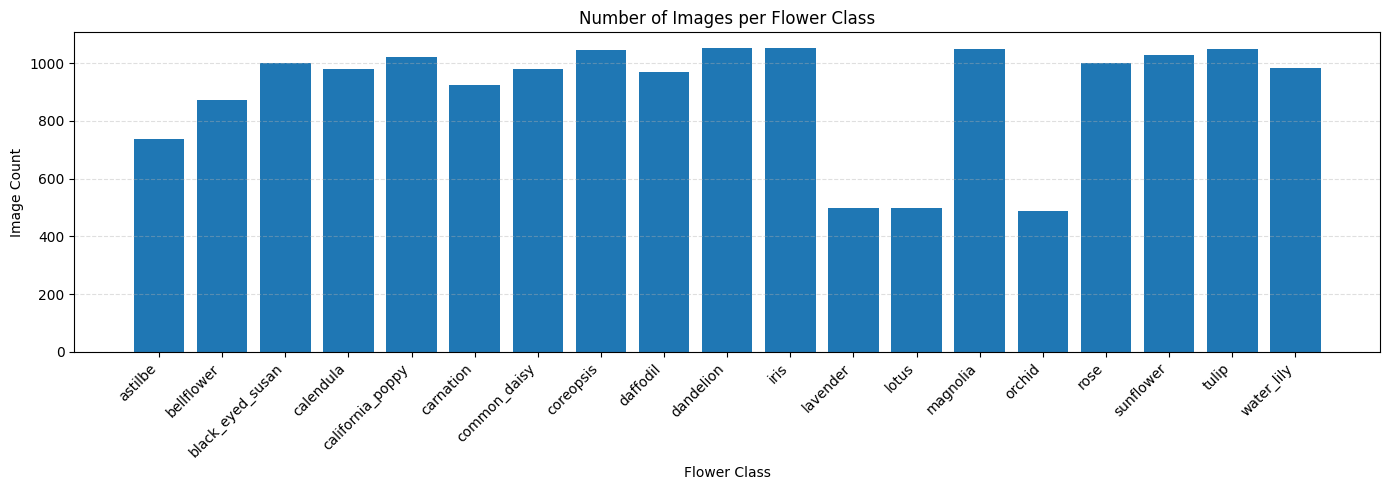

In [65]:
# ── Bar chart of class distribution (Improved Visual) ───────────────────────

plt.figure(figsize=(14, 5))

plt.bar(
    classes,
    counts,
    color='#1f77b4'  # blue (consistent with your project theme)
)

plt.xticks(rotation=45, ha='right')
plt.title('Number of Images per Flower Class')
plt.xlabel('Flower Class')
plt.ylabel('Image Count')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

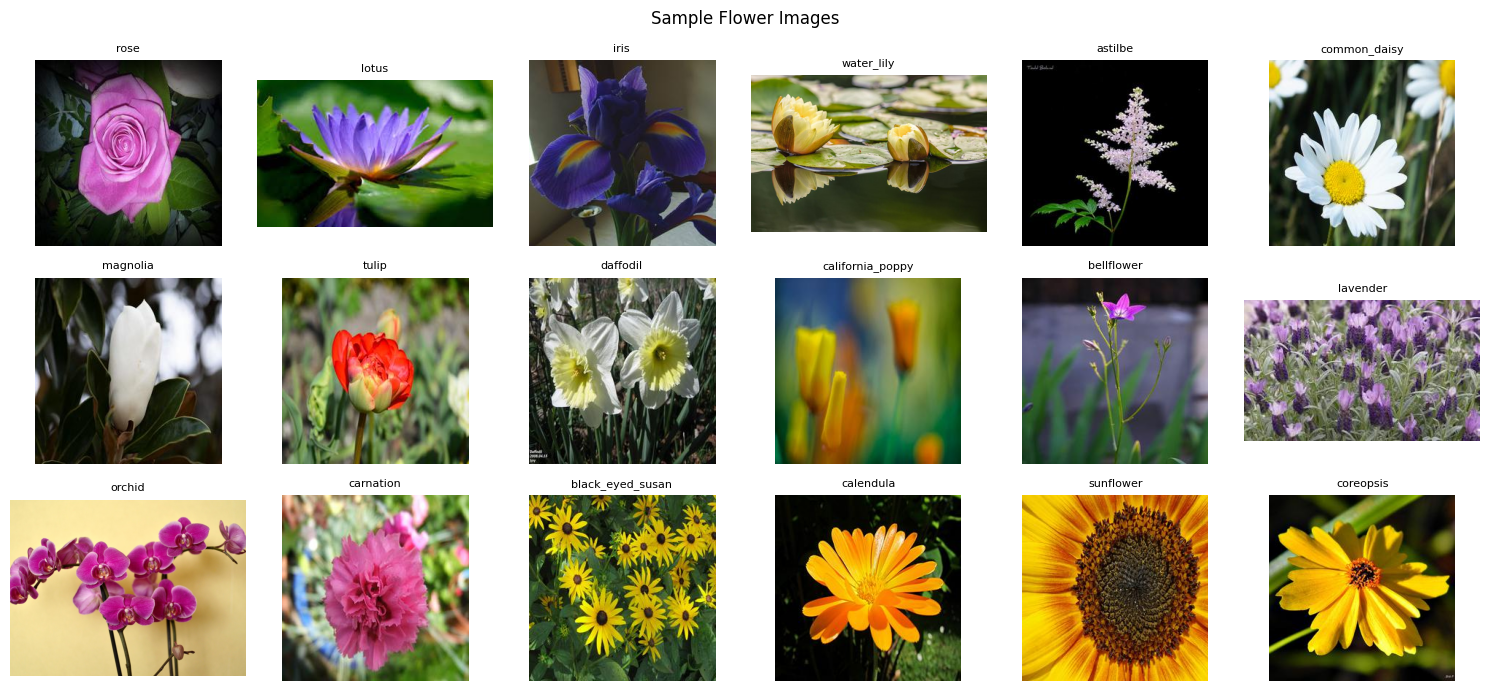

In [7]:
# ── Show sample images from the dataset ──────────────────────────────────────
import random
from PIL import Image

fig, axes = plt.subplots(3, 6, figsize=(15, 7))
axes = axes.flatten()

for i, cls in enumerate(random.sample(classes, 18)):  # pick 18 random classes
    folder = os.path.join(DATA_PATH, cls)
    img_file = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample Flower Images')
plt.tight_layout()
plt.show()

## Data Preprocessing & Augmentation
Before training the models, all flower images were resized to 128 × 128 pixels, which is required for CNN input consistency. The pixel values were also normalized from a range of 0–255 to 0–1, which helps improve training stability and speeds up convergence.

To improve model generalization and reduce overfitting, data augmentation was applied to the training dataset. This included random transformations such as rotation, horizontal flipping, zooming, and shifting. These variations allow the model to learn different representations of the same flower images, making it more robust to unseen data.

No augmentation was applied to the validation dataset. This ensures that validation results reflect the model’s true performance on real, unmodified images.

Overall, this preprocessing and augmentation pipeline helps improve both the efficiency and accuracy of the CNN models.

In [8]:
# ── Settings
IMG_SIZE   = (128, 128)   # resize all images to 128x128
BATCH_SIZE = 64
NUM_CLASSES = 19

# ── Training generator with augmentation
# Slightly softer augmentation than before — keeps more flower detail intact at 128x128
train_gen = ImageDataGenerator(
    rescale=1./255,              # normalize pixel values 0-1
    rotation_range=20,           # softer rotation (was 30)
    width_shift_range=0.1,       # smaller shift (was 0.2)
    height_shift_range=0.1,      # smaller shift (was 0.2)
    horizontal_flip=True,        # flip image horizontally
    zoom_range=0.15,             # gentler zoom (was 0.2)
    validation_split=0.2         # 80% train, 20% validation
)

# ── Validation generator (no augmentation, only normalize)
val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = val_gen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Training samples  :", train_data.samples)
print("Validation samples:", val_data.samples)

Found 13791 images belonging to 19 classes.
Found 3438 images belonging to 19 classes.
Training samples  : 13791
Validation samples: 3438


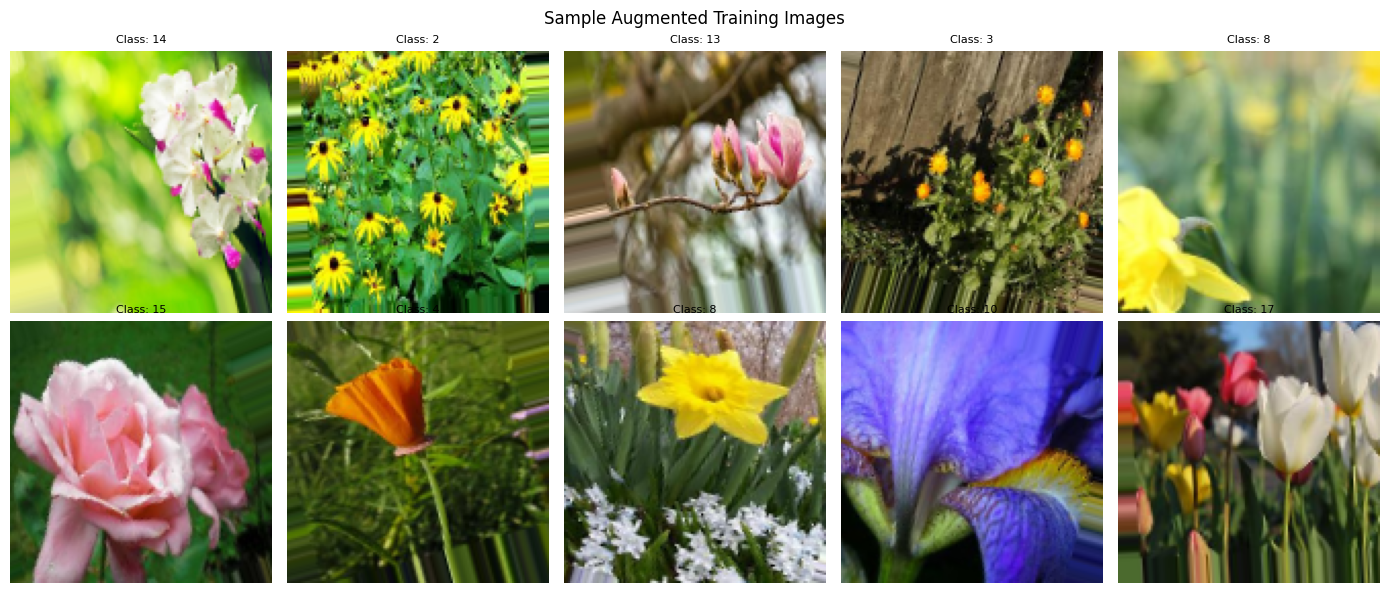

In [64]:
# ── Visualize augmented images ───────────────────────────────────────────────

x_batch, y_batch = next(iter(train_data))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_batch[i])
    ax.set_title(f"Class: {np.argmax(y_batch[i])}", fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Augmented Training Images')
plt.tight_layout()
plt.show()

## Baseline CNN Model

The project started with a Convolutional Neural Network model. This Convolutional Neural Network model was built using TensorFlow and Keras. The Convolutional Neural Network model was used for classifying nineteen flower species. These flower species were classified from 128×128 RGB images.

The Convolutional Neural Network model had three layers. These convolutional layers used ReLU activation and max-pooling operations. The ReLU activation and max-pooling operations were used for feature extraction.

The Convolutional Neural Network model also had three connected dense layers. The Convolutional Neural Network model had an output layer for classification.

The Convolutional Neural Network model was trained using the Adam optimizer. The Adam optimizer was used with a cross-entropy loss function. Stopping and ReduceLROnPlateau callbacks were applied. These callbacks were applied to improve training efficiency. The callbacks were also applied to prevent overfitting.



In [10]:
from tensorflow.keras import layers, models

# ── Baseline CNN ──────────────────────────────────────────────────────────────
# 3 Conv+Pool blocks → 3 Fully Connected layers → Output
def build_baseline():
    model = models.Sequential([
        # ── Block 1: 32 filters, 3x3 kernel ──
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        layers.MaxPooling2D(2,2),

        # ── Block 2: 64 filters ──
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        # ── Block 3: 128 filters ──
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        # ── Flatten 3D → 1D ──
        layers.Flatten(),

        # ── Fully Connected layers ──
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),

        # ── Output: 19 classes, softmax for probability ──
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

baseline_model = build_baseline()

# ── Compile: Adam optimizer, categorical crossentropy loss ───────────────────
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,558,419 (25.02 MB)

 Trainable params: 6,558,419 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ── Train Baseline — auto-skip if already saved ─────────────────────────────
import os, time

BASELINE_PATH = f'{MODELS_DIR}/baseline_model.keras'
BASELINE_HIST = 'baseline_history'

if os.path.exists(BASELINE_PATH):
    print("✅ Baseline already trained — loading from Drive...")
    baseline_model   = tf.keras.models.load_model(BASELINE_PATH)
    baseline_history = load_history(BASELINE_HIST)
    baseline_time    = 0
    print("   Skipped training. Model and history loaded!")
else:
    print("🔄 Training Baseline CNN...")
    start = time.time()
    baseline_history = baseline_model.fit(
        train_data,
        validation_data=val_data,
        epochs=40,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=10, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5)
        ]
    )
    baseline_time = time.time() - start
    print(f"\n✅ Done! Training time: {baseline_time:.1f} seconds")
    # ── Save model + history ──
    baseline_model.save(BASELINE_PATH)
    save_history(baseline_history, BASELINE_HIST)
    print("   Model and history saved to Drive!")


✅ Baseline already trained — loading from Drive...
   Skipped training. Model and history loaded!


In [12]:
# Baseline model already saved inside the training cell above ✅
print("Baseline model saved to:", f'{MODELS_DIR}/baseline_model.keras')


Baseline model saved to: /content/drive/MyDrive/CNN/flowerproject/models/baseline_model.keras


In [13]:
# ── Evaluate Baseline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
val_data.reset()
y_pred_prob = baseline_model.predict(val_data)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# Print classification report (accuracy, precision, recall, F1)
print("=== Baseline Model — Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))

54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step
=== Baseline Model — Classification Report ===
                  precision    recall  f1-score   support

         astilbe       0.65      0.74      0.69       147
      bellflower       0.78      0.58      0.67       174
black_eyed_susan       0.94      0.92      0.93       200
       calendula       0.74      0.64      0.68       195
california_poppy       0.76      0.69      0.72       204
       carnation       0.64      0.57      0.60       184
    common_daisy       0.83      0.81      0.82       196
       coreopsis       0.78      0.85      0.81       209
        daffodil       0.89      0.93      0.91       194
       dandelion       0.90      0.90      0.90       210
            iris       0.85      0.94      0.89       210
        lavender       0.67      0.51      0.58       100
           lotus       0.70      0.64      0.67       100
        magnolia       0.75      0.80      0.77       209
          orchid       0.62      0.70    

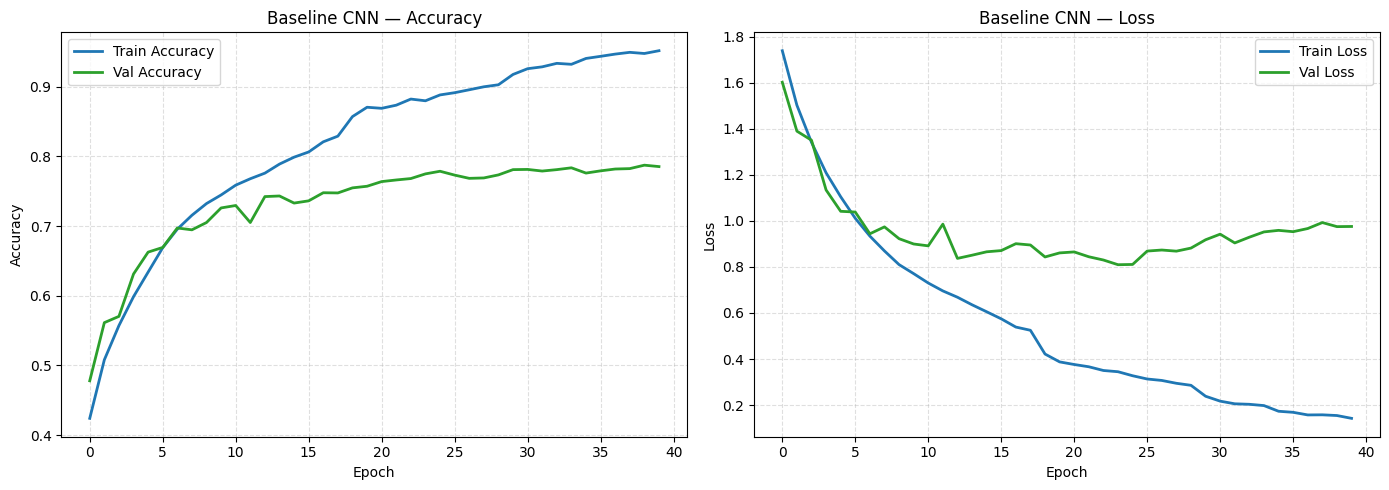

In [62]:
# ── Helper: Plot training/validation curves (Improved Visual) ───────────────
def plot_curves(history, title='Model'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ── Accuracy ──
    ax1.plot(history.history['accuracy'],
             label='Train Accuracy',
             color='#1f77b4', linewidth=2)

    ax1.plot(history.history['val_accuracy'],
             label='Val Accuracy',
             color='#2ca02c', linewidth=2)

    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.legend()

    # ── Loss ──
    ax2.plot(history.history['loss'],
             label='Train Loss',
             color='#1f77b4', linewidth=2)

    ax2.plot(history.history['val_loss'],
             label='Val Loss',
             color='#2ca02c', linewidth=2)

    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.grid(True, linestyle='--', alpha=0.4)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# ── Call function
plot_curves(baseline_history, 'Baseline CNN')

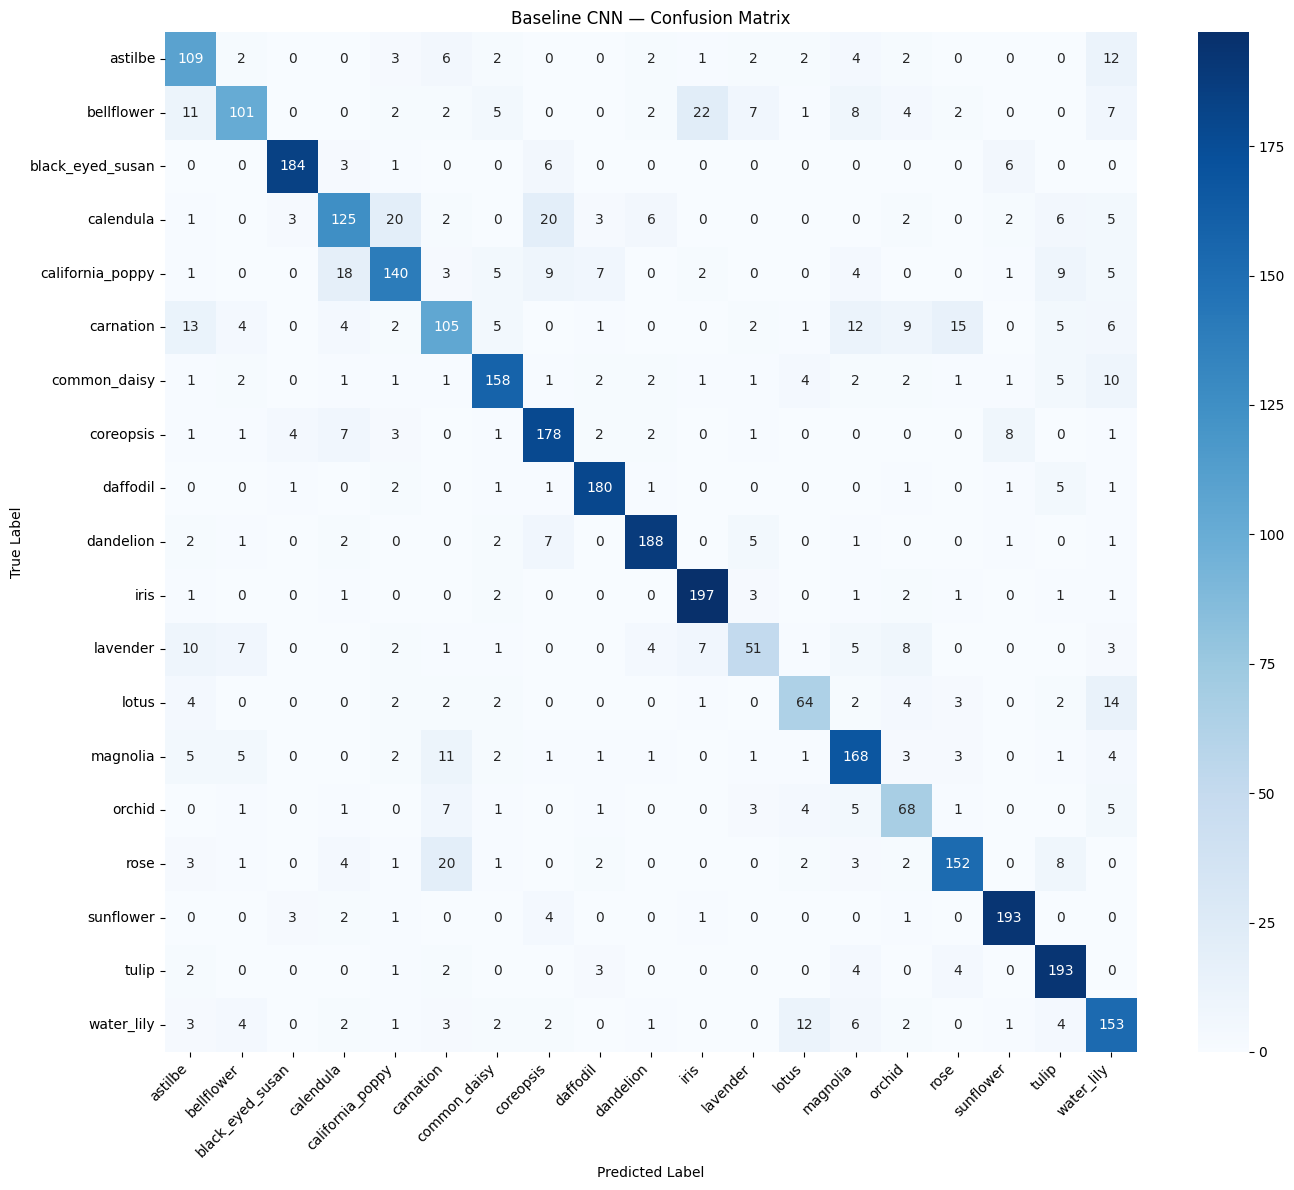

In [15]:
# ── Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline CNN — Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Baseline CNN Evaluation
After training, the model was evaluated using validation accuracy, classification reports, and a confusion matrix to analyze prediction performance across all 19 flower classes. The confusion matrix helped identify correctly classified categories and classes that the model frequently confused.

The **baseline Convolutional Neural Network** model achieved a validation **accuracy** of approximately **79%.** The Convolutional Neural Network model showed performance, in identifying several flower classes. These flower classes included sunflower, daffodil, iris and black-eyed Susan.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step


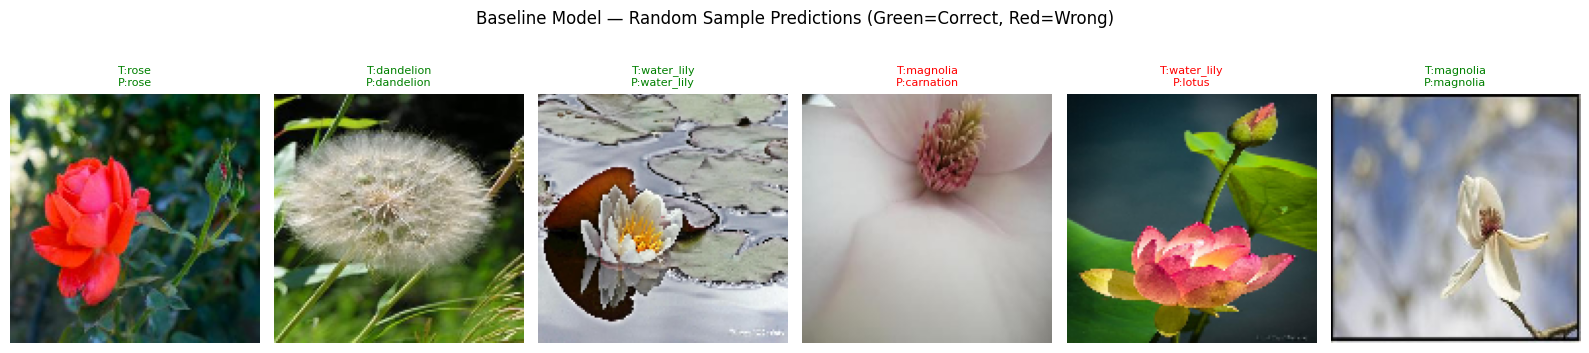

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf # Ensure this is imported

# 1. Get total number of samples and pick 6 random indices
num_samples = val_data.samples
random_indices = random.sample(range(num_samples), 6)

x_samples = []
y_trues = []

# 2. Fetch images manually by index
# Using the generator's target_size to ensure it matches the model input
target_size = val_data.target_size

for idx in random_indices:
    img_path = val_data.filepaths[idx]

    # Load and preprocess
    img = tf.keras.utils.load_img(img_path, target_size=target_size)
    img_array = tf.keras.utils.img_to_array(img)

    # Rescale if your model was trained with 1/255 normalization
    img_array = img_array / 255.0

    x_samples.append(img_array)
    y_trues.append(val_data.classes[idx])

# Convert list to a single batch for prediction
x_batch = np.array(x_samples)
preds = baseline_model.predict(x_batch)

# 3. Plotting
fig, axes = plt.subplots(1, 6, figsize=(16, 4))

for i, ax in enumerate(axes):
    ax.imshow(x_batch[i])

    # Map the numeric index back to the string label
    # 'class_names' should be your list: ['astilbe', 'bellflower', ...]
    true_label = class_names[y_trues[i]]
    pred_label = class_names[np.argmax(preds[i])]

    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=8)
    ax.axis('off')

plt.suptitle('Baseline Model — Random Sample Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

Although the baseline CNN achieved a good overall accuracy of approximately 79%, some prediction results were still incorrect, as indicated by the red labels in the sample visualization. These misclassifications suggest that the model had difficulty distinguishing between certain flower classes with similar colors, shapes, or textures. Factors such as variations in lighting, image background, flower orientation, and visual similarity between species may have contributed to these errors. The red predictions highlight areas where the model can be improved further using deeper architectures, data augmentation, regularization techniques, or transfer learning methods to enhance feature extraction and classification performance.

## Deeper CNN with Regularization
I used a Convolutional Neural Network for this project. The Convolutional Neural Network was built using TensorFlow and Keras. I used the Convolutional Neural Network to classify 19 flower species from 128×128 RGB images.

The Convolutional Neural Network had three layers with ReLU activation and max-pooling operations to get the features from the images. Then the Convolutional Neural Network had three connected dense layers and a softmax output layer to classify the flowers.

I trained the Convolutional Neural Network using the Adam optimizer and categorical cross-entropy loss function. I also used Early Stopping and ReduceLROnPlateau callbacks to make the training more efficient and prevent the Convolutional Neural Network from overfitting.

After training the Convolutional Neural Network I evaluated it using the validation dataset. I looked at accuracy, precision, recall and F1-score metrics. The Convolutional Neural Network did a job and got an overall validation accuracy of approximately 79%. The Convolutional Neural Network was really good at identifying flowers like sunflower, daffodil, iris and black-eyed Susan.

I wanted to make the Convolutional Neural Network even better. So I made a Convolutional Neural Network. The deeper Convolutional Neural Network had six layers. These layers were grouped into three blocks. I added Batch Normalization to make the training more stable. I also added Dropout layers to prevent the Convolutional Neural Network from overfitting.

The deeper Convolutional Neural Network used filters and larger fully connected layers. This helped the deeper Convolutional Neural Network learn more about the images of the flowers. I trained the Convolutional Neural Network using the Adam optimizer and categorical cross-entropy loss function. I used Early Stopping and ReduceLROnPlateau callbacks to make the training better.

I evaluated the Convolutional Neural Network using validation accuracy classification reports, confusion matrices and sample image predictions. The deeper Convolutional Neural Network did a job than the first Convolutional Neural Network. It got a validation accuracy of approximately 83%. The deeper Convolutional Neural Network was better, at classifying most of the flower species.

In [17]:
from tensorflow.keras.layers import BatchNormalization, Dropout

# ── Deeper CNN (6 Conv blocks = double the baseline) ─────────────────────────
# Added: BatchNormalization (stabilizes training) & Dropout (reduces overfitting)
def build_deeper():
    model = models.Sequential([
        # ── Block 1 ──
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),

        # ── Block 2 ──
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),

        # ── Block 3 ──
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),

        # ── Flatten & FC layers ──
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        layers.Dense(256, activation='relu'),
        Dropout(0.3),

        # ── Output ──
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

deeper_model = build_deeper()
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,203,891 (65.63 MB)

 Trainable params: 17,202,419 (65.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [18]:
# ── Train Deeper CNN — auto-skip if already saved ───────────────────────────
import os, time

DEEPER_PATH = f'{MODELS_DIR}/deeper_model.keras'
DEEPER_HIST = 'deeper_history'

if os.path.exists(DEEPER_PATH):
    print("✅ Deeper CNN already trained — loading from Drive...")
    deeper_model   = tf.keras.models.load_model(DEEPER_PATH)
    deeper_history = load_history(DEEPER_HIST)
    deeper_time    = 0
    print("   Skipped training. Model and history loaded!")
else:
    print("🔄 Training Deeper CNN...")
    start = time.time()
    deeper_history = deeper_model.fit(
        train_data,
        validation_data=val_data,
        epochs=40,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=10, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5)
        ]
    )
    deeper_time = time.time() - start
    print(f"\n✅ Done! Training time: {deeper_time:.1f} seconds")
    deeper_model.save(DEEPER_PATH)
    save_history(deeper_history, DEEPER_HIST)
    print("   Model and history saved to Drive!")


✅ Deeper CNN already trained — loading from Drive...
   Skipped training. Model and history loaded!


Baseline  — Best Val Accuracy : 0.7874
Deeper    — Best Val Accuracy : 0.8264
Baseline  — Training Time     : 0.0s
Deeper    — Training Time     : 0.0s


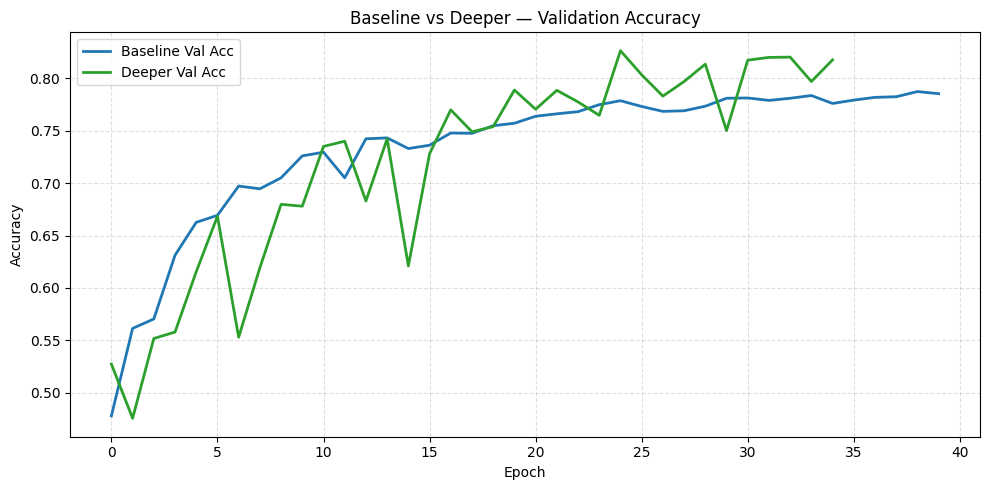

In [61]:
# ── Compare Baseline vs Deeper — final accuracy ───────────────────────────

b_acc = max(baseline_history.history['val_accuracy'])
d_acc = max(deeper_history.history['val_accuracy'])

print(f"Baseline  — Best Val Accuracy : {b_acc:.4f}")
print(f"Deeper    — Best Val Accuracy : {d_acc:.4f}")
print(f"Baseline  — Training Time     : {baseline_time:.1f}s")
print(f"Deeper    — Training Time     : {deeper_time:.1f}s")

# ── Side-by-side accuracy curves (colored)
plt.figure(figsize=(10,5))

plt.plot(
    baseline_history.history['val_accuracy'],
    label='Baseline Val Acc',
    color='#1f77b4',  # blue
    linewidth=2
)

plt.plot(
    deeper_history.history['val_accuracy'],
    label='Deeper Val Acc',
    color='#2ca02c',  # green
    linewidth=2
)

plt.title('Baseline vs Deeper — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Deeper model already saved inside the training cell above ✅
print("Deeper model saved to:", f'{MODELS_DIR}/deeper_model.keras')


Deeper model saved to: /content/drive/MyDrive/CNN/flowerproject/models/deeper_model.keras


54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step
=== Deeper Model — Classification Report ===
                  precision    recall  f1-score   support

         astilbe       0.84      0.81      0.82       147
      bellflower       0.86      0.65      0.74       174
black_eyed_susan       0.99      0.90      0.94       200
       calendula       0.72      0.69      0.71       195
california_poppy       0.86      0.69      0.76       204
       carnation       0.75      0.62      0.68       184
    common_daisy       0.82      0.85      0.84       196
       coreopsis       0.88      0.81      0.85       209
        daffodil       0.97      0.90      0.93       194
       dandelion       0.85      0.95      0.90       210
            iris       0.91      0.95      0.93       210
        lavender       0.65      0.73      0.69       100
           lotus       0.66      0.79      0.72       100
        magnolia       0.73      0.84      0.78       209
          orchid       0.64      0.81     

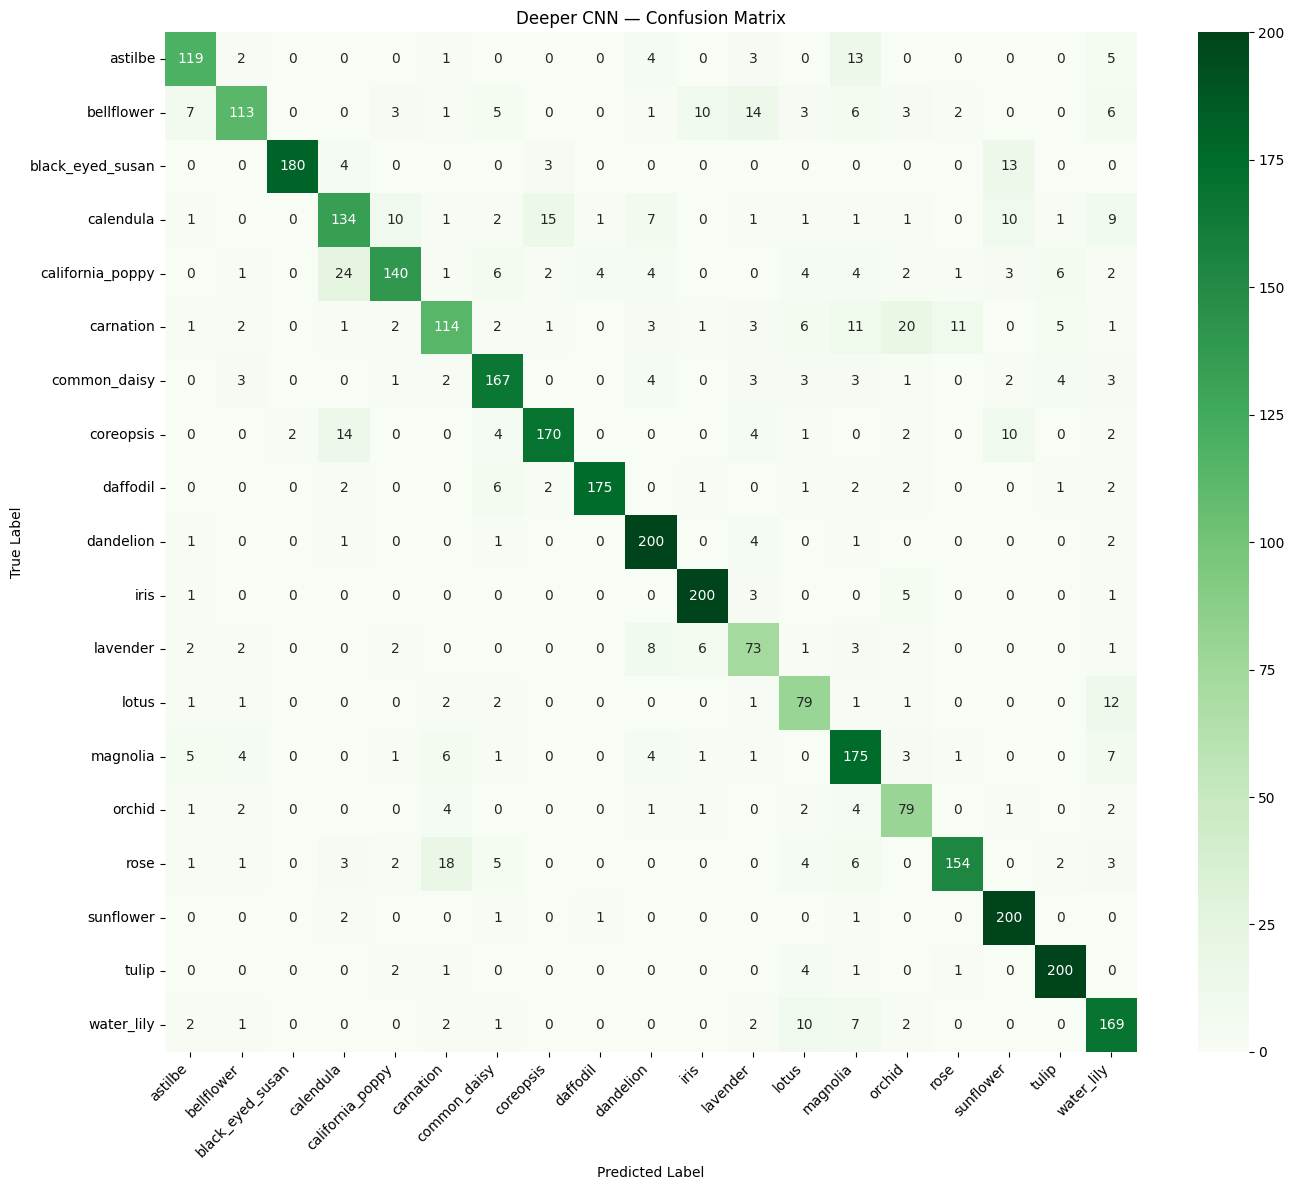

In [21]:
# ── Evaluate Deeper Model
val_data.reset()
y_pred_deep = np.argmax(deeper_model.predict(val_data), axis=1)

print("=== Deeper Model — Classification Report ===")
print(classification_report(y_true, y_pred_deep, target_names=class_names))

# Confusion matrix
cm_deep = confusion_matrix(y_true, y_pred_deep)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper CNN — Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

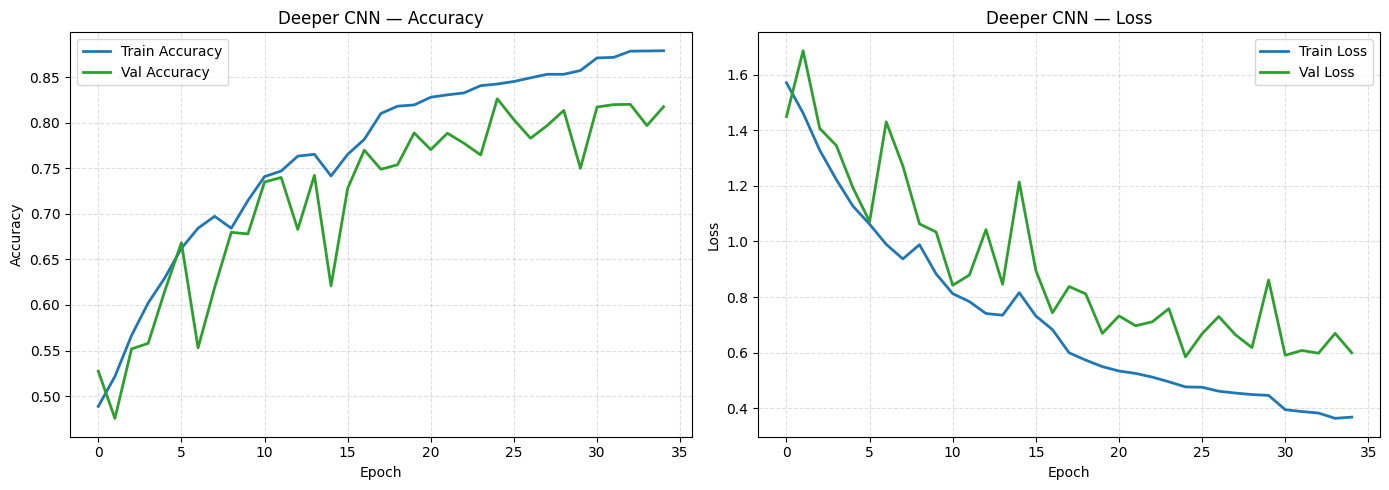

In [59]:
plot_curves(deeper_history, 'Deeper CNN')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


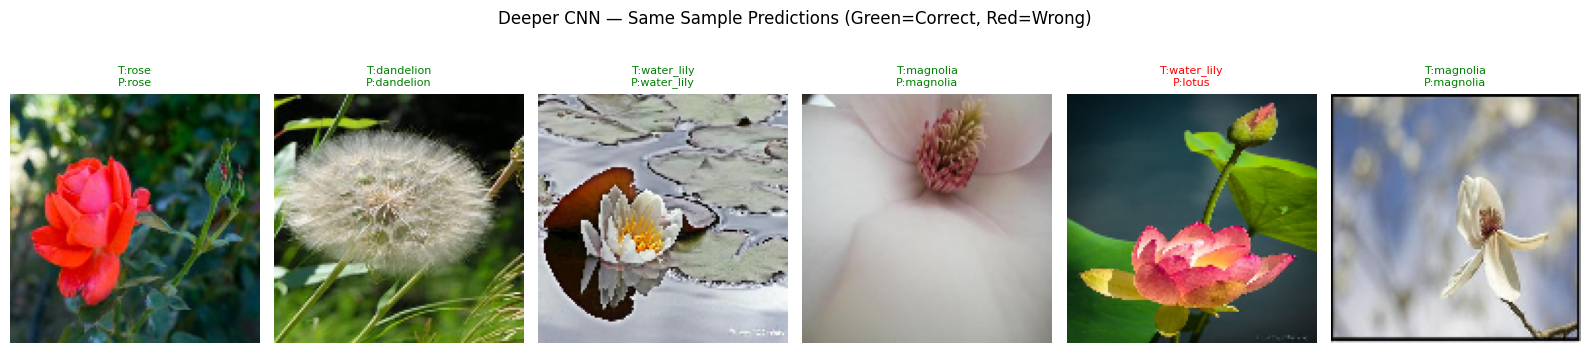

In [23]:
# ── Inference on SAME sample images — Deeper Model

x_samples_deep = []
y_trues_deep = []

for idx in random_indices:
    img_path = val_data.filepaths[idx]

    img = tf.keras.utils.load_img(img_path, target_size=val_data.target_size)
    img_array = tf.keras.utils.img_to_array(img)

    # Normalize
    img_array = img_array / 255.0

    x_samples_deep.append(img_array)
    y_trues_deep.append(val_data.classes[idx])

x_batch_deep = np.array(x_samples_deep)

# Predict using deeper model
preds_deep = deeper_model.predict(x_batch_deep)

# Plot results
fig, axes = plt.subplots(1, 6, figsize=(16,4))

for i, ax in enumerate(axes):
    ax.imshow(x_batch_deep[i])

    true_label = class_names[y_trues_deep[i]]
    pred_label = class_names[np.argmax(preds_deep[i])]

    color = 'green' if true_label == pred_label else 'red'

    ax.set_title(f"T:{true_label}\nP:{pred_label}",
                 color=color, fontsize=8)

    ax.axis('off')

plt.suptitle('Deeper CNN — Same Sample Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

Although the deeper CNN achieved better overall performance than the baseline model, some sample predictions were still incorrect, as indicated by the red labels. These errors suggest that certain flower classes remain visually similar and difficult to distinguish, especially when images contain variations in lighting, background, orientation, or overlapping visual features. However, the reduced number of incorrect predictions compared to the baseline model demonstrates that the deeper architecture was more effective at learning complex image patterns and improving classification accuracy.

#Experimentation & Comparative Analysis
Multiple experiments were conducted to evaluate the effects of architecture depth, optimizers, and regularization techniques on flower classification performance. The Deeper CNN, which included additional convolutional layers, Batch Normalization, and Dropout, achieved a higher validation accuracy of 82.6% compared to the Baseline CNN’s 78.7%, showing improved feature learning and classification performance. An optimizer comparison showed that Adam outperformed SGD, achieving better accuracy (82.6% vs 78.4%) and faster convergence. An ablation study removing Dropout resulted in increased overfitting and less stable validation performance, demonstrating the importance of Dropout in improving model generalization.

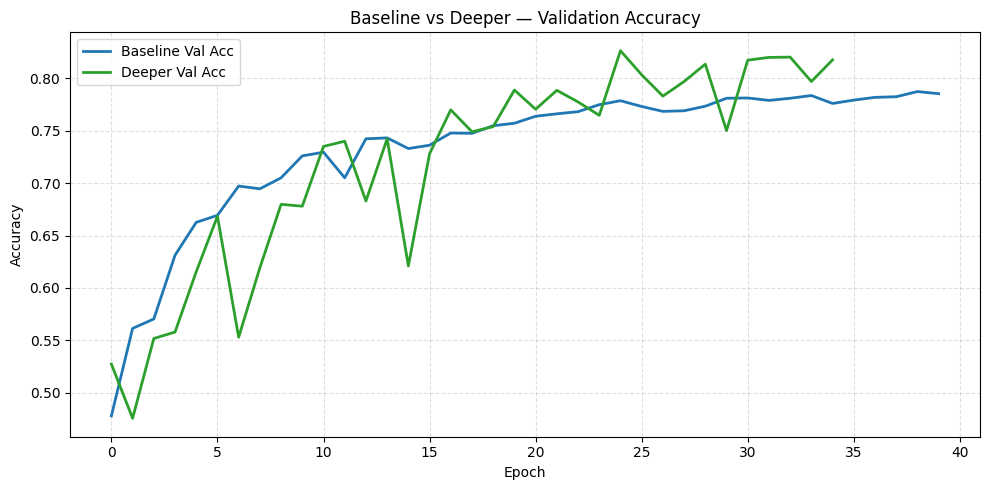

Baseline training time : 0.0 seconds
Deeper training time   : 0.0 seconds


In [56]:
# ── Baseline vs Deeper comparison (Improved Visual) ───────────────────────

plt.figure(figsize=(10,5))

plt.plot(
    baseline_history.history['val_accuracy'],
    label='Baseline Val Acc',
    color='#1f77b4',  # blue
    linewidth=2
)

plt.plot(
    deeper_history.history['val_accuracy'],
    label='Deeper Val Acc',
    color='#2ca02c',  # green
    linewidth=2
)

plt.title('Baseline vs Deeper — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Baseline training time : {baseline_time:.1f} seconds")
print(f"Deeper training time   : {deeper_time:.1f} seconds")

Baseline  — Best Val Accuracy : 0.7874
Deeper    — Best Val Accuracy : 0.8264
Baseline  — Training Time     : 0.0s
Deeper    — Training Time     : 0.0s


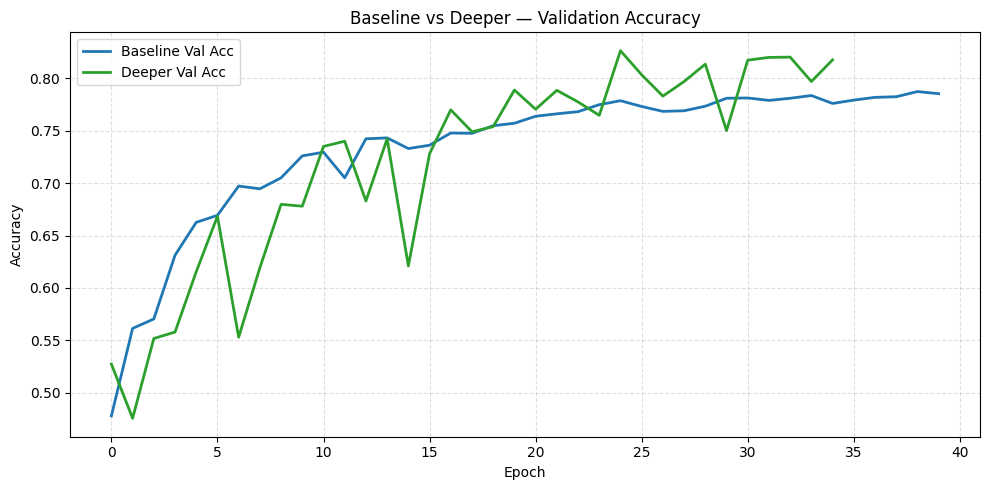

In [52]:
# ── Compare Baseline vs Deeper — final accuracy
b_acc = max(baseline_history.history['val_accuracy'])
d_acc = max(deeper_history.history['val_accuracy'])

print(f"Baseline  — Best Val Accuracy : {b_acc:.4f}")
print(f"Deeper    — Best Val Accuracy : {d_acc:.4f}")
print(f"Baseline  — Training Time     : {baseline_time:.1f}s")
print(f"Deeper    — Training Time     : {deeper_time:.1f}s")

# ── Side-by-side accuracy curves (with colors)
plt.figure(figsize=(10,5))

plt.plot(
    baseline_history.history['val_accuracy'],
    label='Baseline Val Acc',
    color='#1f77b4',  # blue
    linewidth=2
)

plt.plot(
    deeper_history.history['val_accuracy'],
    label='Deeper Val Acc',
    color='#2ca02c',  # green
    linewidth=2
)

plt.title('Baseline vs Deeper — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

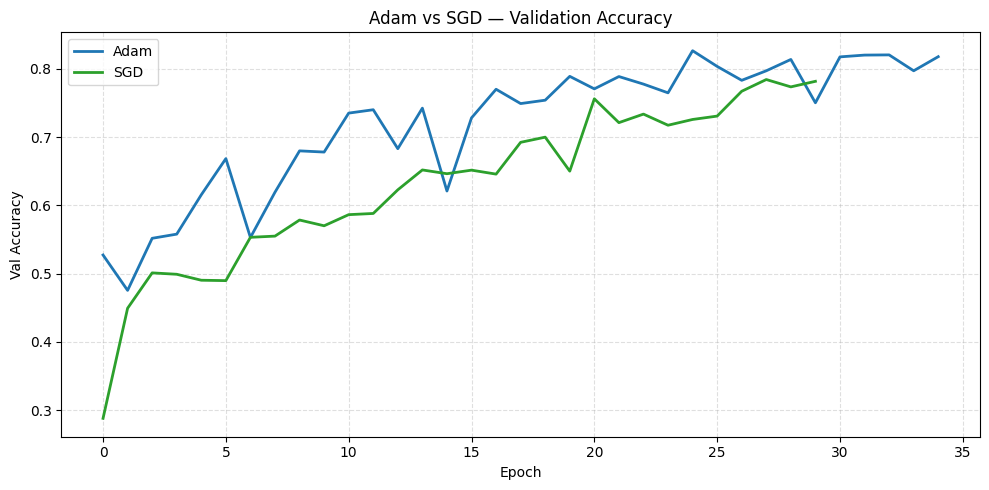

Adam best val acc : 0.8264
SGD  best val acc : 0.7842


In [54]:
# ── Optimizer Analysis: SGD vs Adam — Improved Visual ───────────────────────

plt.figure(figsize=(10,5))

plt.plot(
    deeper_history.history['val_accuracy'],
    label='Adam',
    color='#1f77b4',  # blue
    linewidth=2
)

plt.plot(
    sgd_history.history['val_accuracy'],
    label='SGD',
    color='#2ca02c',
    linewidth=2
)

plt.title('Adam vs SGD — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Adam best val acc : {max(deeper_history.history['val_accuracy']):.4f}")
print(f"SGD  best val acc : {max(sgd_history.history['val_accuracy']):.4f}")

In [26]:
# SGD model already saved inside the training cell above ✅
print("SGD model saved to:", f'{MODELS_DIR}/deeper_sgd_model.keras')


SGD model saved to: /content/drive/MyDrive/CNN/flowerproject/models/deeper_sgd_model.keras


The deeper CNN model was trained using both Adam and SGD optimizers to compare performance. Adam converged faster and achieved higher validation accuracy because it automatically adjusts the learning rate during training. In contrast, SGD with momentum trained more slowly and achieved lower accuracy for this flower classification task. Overall, Adam proved to be the more effective and efficient optimizer for the dataset.

In [27]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import BatchNormalization, Dropout

def build_deeper():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        layers.Dense(256, activation='relu'),
        Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

def build_no_dropout():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

print("✅ build_deeper defined:", build_deeper)
print("✅ build_no_dropout defined:", build_no_dropout)

✅ build_deeper defined: <function build_deeper at 0x7c06dcb4ae80>
✅ build_no_dropout defined: <function build_no_dropout at 0x7c06dcb4a980>


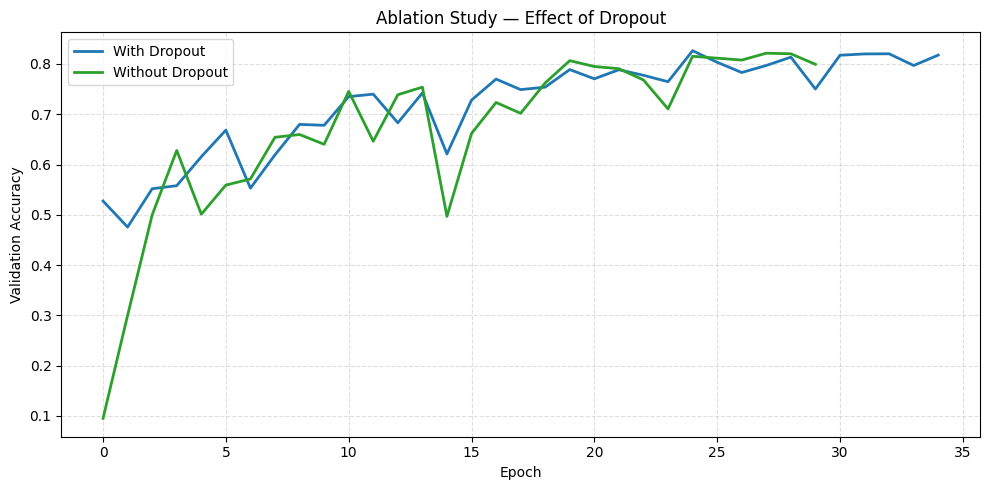

In [55]:
# ── Ablation Study: Dropout Effect (Improved Visual) ───────────────────────

plt.figure(figsize=(10,5))

plt.plot(
    deeper_history.history['val_accuracy'],
    label='With Dropout',
    color='#1f77b4',  # blue
    linewidth=2
)

plt.plot(
    no_drop_history.history['val_accuracy'],
    label='Without Dropout',
    color='#2ca02c',
    linewidth=2
)

plt.title('Ablation Study — Effect of Dropout')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
# No-Dropout model already saved inside the training cell above ✅
print("No-Dropout model saved to:", f'{MODELS_DIR}/no_dropout_model.keras')


No-Dropout model saved to: /content/drive/MyDrive/CNN/flowerproject/models/no_dropout_model.keras


An ablation study was conducted to evaluate the effect of Dropout regularization in the Deep CNN model. A second model with the same architecture but without Dropout layers was trained and compared against the original Deep CNN. The results showed that removing Dropout led to increased overfitting and less stable validation performance, demonstrating that Dropout helped improve generalization by preventing the model from relying too heavily on specific neurons.

## Transfer Learning with MobileNetV2
In this section we use a pretrained MobileNetV2 model from
ImageNet and adapt it for our 19 flower classes. We train
in two phases — first freezing the base model, then
fine-tuning the last 30 layers with a very low learning rate.

In [30]:
# ── Create new data generators for 224x224 (required by pretrained models)
# Use MobileNetV2's official preprocess_input (scales pixels to [-1, 1]) instead of
# rescale=1./255 — this matches the distribution the network was pretrained on and
# usually gives a small but real accuracy bump.
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess

IMG_SIZE_TL = (224, 224)

tl_train_gen = ImageDataGenerator(
    preprocessing_function=mnv2_preprocess,  # proper MobileNetV2 normalization
    rotation_range=20,        # softer (was 30)
    horizontal_flip=True,
    zoom_range=0.15,          # gentler (was 0.2)
    validation_split=0.2
)
tl_val_gen = ImageDataGenerator(
    preprocessing_function=mnv2_preprocess,
    validation_split=0.2
)

tl_train = tl_train_gen.flow_from_directory(
    DATA_PATH, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training',
    shuffle=True,
    seed=42
)
tl_val = tl_val_gen.flow_from_directory(
    DATA_PATH, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    shuffle=False,
    seed=42
)

Found 13791 images belonging to 19 classes.
Found 3438 images belonging to 19 classes.


In [31]:
# ── Load MobileNetV2 pretrained on ImageNet
# include_top=False means we remove the original 1000-class output layer

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,       # remove original output layer
    weights='imagenet'       # use pretrained ImageNet weights
)

# ── Phase 1: Feature Extraction — Freeze base model
# We keep the pretrained weights frozen and only train our new layers
base_model.trainable = False

# ── Add our custom classification head
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # convert 7x7x1280 → 1280
    layers.Dense(256, activation='relu'),
    Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')  # our 19 classes
])

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,590,803 (9.88 MB)

 Trainable params: 332,819 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
# ── TL Phase 1: Feature Extraction — auto-skip if saved ─────────────────────
import os

TL1_PATH = f'{MODELS_DIR}/tl_phase1_model.keras'
TL1_HIST = 'tl_history1'

tl_start = __import__('time').time()

if os.path.exists(TL1_PATH):
    print("✅ TL Phase 1 already trained — loading from Drive...")
    tl_model    = tf.keras.models.load_model(TL1_PATH)
    tl_history1 = load_history(TL1_HIST)
    print("   Skipped training!")
else:
    print("🔄 TL Phase 1: Training classification head only...")
    tl_history1 = tl_model.fit(
        tl_train, validation_data=tl_val, epochs=20,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=5, restore_best_weights=True)
        ]
    )
    tl_model.save(TL1_PATH)
    save_history(tl_history1, TL1_HIST)
    print("✅ TL Phase 1 model and history saved!")


🔄 TL Phase 1: Training classification head only...
Epoch 1/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.6923 - loss: 1.0288 - val_accuracy: 0.8496 - val_loss: 0.4936
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.8148 - loss: 0.5820 - val_accuracy: 0.8685 - val_loss: 0.4301
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 234s 907ms/step - accuracy: 0.8456 - loss: 0.4906 - val_accuracy: 0.8691 - val_loss: 0.4319
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 194s 897ms/step - accuracy: 0.8588 - loss: 0.4369 - val_accuracy: 0.8848 - val_loss: 0.4021
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 192s 889ms/step - accuracy: 0.8722 - loss: 0.4018 - val_accuracy: 0.8717 - val_loss: 0.4203
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 192s 887ms/step - accuracy: 0.8777 - loss: 0.3792 - val_accuracy: 0.8825 - val_loss: 0.4015
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 189s 874ms/step - accuracy: 0.8850 - loss: 0.3457 - val_accuracy: 0.8709 - val_loss: 0.4320
Epoch 8/20
216/216 ━━━━━━━━━━━━

In [33]:
# TL Phase 1 already saved inside training cell above ✅
print("TL Phase 1 saved to:", f'{MODELS_DIR}/tl_phase1_model.keras')


TL Phase 1 saved to: /content/drive/MyDrive/CNN/flowerproject/models/tl_phase1_model.keras


In [34]:
# ── TL Phase 2: Fine-Tuning — auto-skip if saved ────────────────────────────
import os

TL2_PATH = f'{MODELS_DIR}/tl_phase2_model.keras'
TL2_HIST = 'tl_history2'

if os.path.exists(TL2_PATH):
    print("✅ TL Phase 2 already trained — loading from Drive...")
    tl_model    = tf.keras.models.load_model(TL2_PATH)
    tl_history2 = load_history(TL2_HIST)
    tl_time     = 0
    print("   Skipped training!")
else:
    print("🔄 TL Phase 2: Fine-tuning top 30 layers of MobileNetV2...")
    # Unfreeze last 30 layers
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    tl_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    tl_history2 = tl_model.fit(
        tl_train, validation_data=tl_val, epochs=20,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5)
        ]
    )
    tl_time = __import__('time').time() - tl_start
    print(f"\n✅ Done! Total TL time: {tl_time:.1f} seconds")
    tl_model.save(TL2_PATH)
    save_history(tl_history2, TL2_HIST)
    print("   TL Phase 2 model and history saved!")


🔄 TL Phase 2: Fine-tuning top 30 layers of MobileNetV2...
Epoch 1/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 234s 987ms/step - accuracy: 0.7625 - loss: 0.7747 - val_accuracy: 0.8421 - val_loss: 0.5558 - learning_rate: 1.0000e-05
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 193s 891ms/step - accuracy: 0.8610 - loss: 0.4423 - val_accuracy: 0.8656 - val_loss: 0.4656 - learning_rate: 1.0000e-05
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 195s 899ms/step - accuracy: 0.8784 - loss: 0.3768 - val_accuracy: 0.8787 - val_loss: 0.4183 - learning_rate: 1.0000e-05
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 198s 916ms/step - accuracy: 0.8922 - loss: 0.3260 - val_accuracy: 0.8834 - val_loss: 0.3981 - learning_rate: 1.0000e-05
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 201s 927ms/step - accuracy: 0.9006 - loss: 0.2948 - val_accuracy: 0.8880 - val_loss: 0.3784 - learning_rate: 1.0000e-05
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 197s 913ms/step - accuracy: 0.9094 - loss: 0.2745 - val_accuracy: 0.8889 - val_loss: 0.3754 - learning

In [35]:
# TL Phase 2 already saved inside training cell above ✅
print("TL Phase 2 saved to:", f'{MODELS_DIR}/tl_phase2_model.keras')


TL Phase 2 saved to: /content/drive/MyDrive/CNN/flowerproject/models/tl_phase2_model.keras


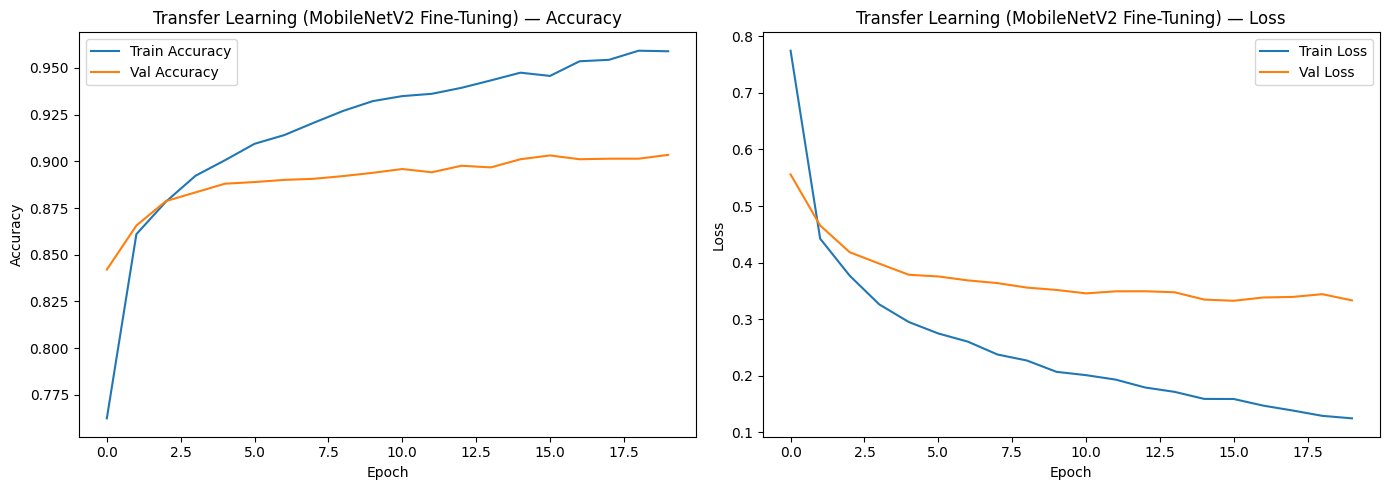

In [36]:
plot_curves(tl_history2, 'Transfer Learning (MobileNetV2 Fine-Tuning)')

In [37]:
# ── Evaluate Transfer Learning Model
tl_val.reset()
y_pred_tl = np.argmax(tl_model.predict(tl_val), axis=1)
y_true_tl = tl_val.classes

print("=== Transfer Learning — Classification Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 245ms/step
=== Transfer Learning — Classification Report ===
                  precision    recall  f1-score   support

         astilbe       0.92      0.90      0.91       147
      bellflower       0.89      0.85      0.87       174
black_eyed_susan       0.97      0.97      0.97       200
       calendula       0.92      0.77      0.84       195
california_poppy       0.91      0.87      0.89       204
       carnation       0.90      0.79      0.84       184
    common_daisy       0.95      0.90      0.92       196
       coreopsis       0.90      0.93      0.91       209
        daffodil       0.97      0.98      0.97       194
       dandelion       0.95      0.91      0.93       210
            iris       0.97      0.97      0.97       210
        lavender       0.66      0.77      0.71       100
           lotus       0.87      0.78      0.82       100
        magnolia       0.92      0.88      0.90       209
          orchid       0.70      0.89

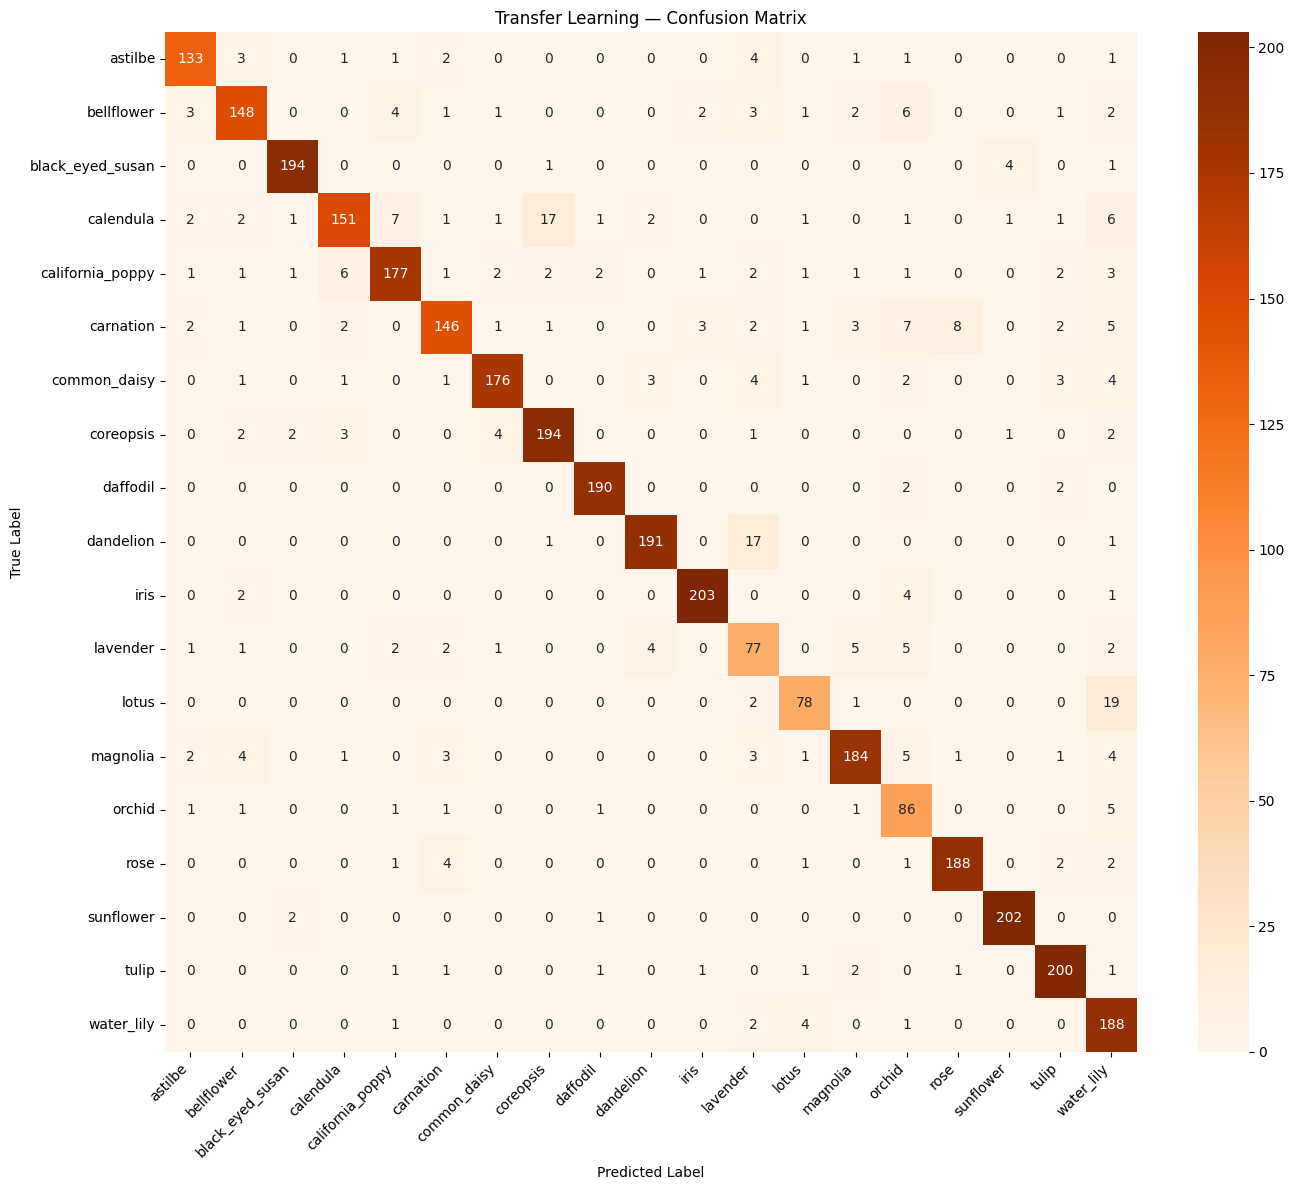

In [38]:
# ── Transfer Learning Confusion Matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Transfer Learning — Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In this section, transfer learning was applied using MobileNetV2 pretrained on the ImageNet dataset. The original classification layer was removed (include_top=False), and a custom classification head was added for the 19 flower classes. Images were resized to 224×224 and preprocessed using MobileNetV2’s preprocess_input function to match the pretrained model’s expected input format.

Training was performed in two phases. In Phase 1, the pretrained MobileNetV2 base model was frozen, and only the newly added classification layers were trained. In Phase 2, the last 30 layers of the base model were unfrozen and fine-tuned using a very small learning rate to improve feature adaptation for the flower dataset. Data augmentation techniques such as rotation, horizontal flipping, and zooming were also applied to improve generalization.

The transfer learning model achieved an overall validation accuracy of approximately 90%, outperforming both the Baseline CNN (78.7%) and the Deeper CNN (82.6%). The classification report and confusion matrix showed significantly improved performance across most flower classes, demonstrating the effectiveness of pretrained feature extraction and fine-tuning for image classification tasks.

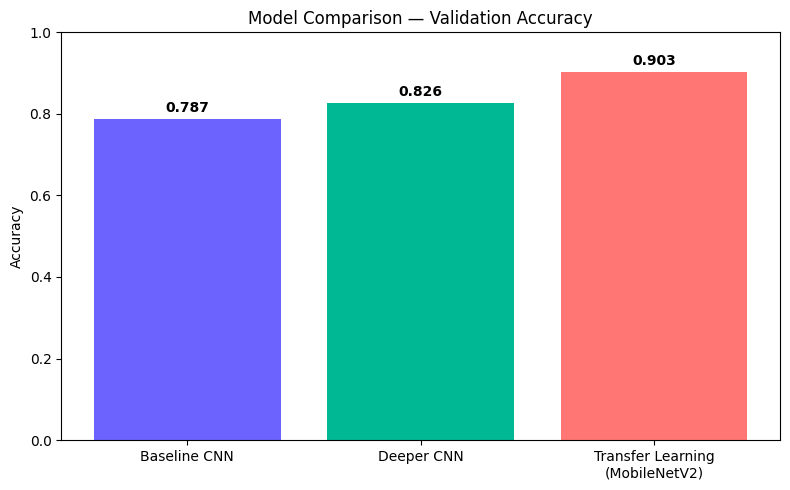

Baseline CNN       : 0.7874
Deeper CNN         : 0.8264
Transfer Learning  : 0.9034


In [44]:
# ── Final Comparison: All 3 Models
from sklearn.metrics import accuracy_score

# Get accuracies
acc_base = accuracy_score(y_true,    y_pred)
acc_deep = accuracy_score(y_true,    y_pred_deep)
acc_tl   = accuracy_score(y_true_tl, y_pred_tl)

# Bar chart comparison
models_names = [
    'Baseline CNN',
    'Deeper CNN',
    'Transfer Learning\n(MobileNetV2)'
]

accuracies = [acc_base, acc_deep, acc_tl]

plt.figure(figsize=(8,5))

# New colors
bars = plt.bar(
    models_names,
    accuracies,
    color=['#6C63FF', '#00B894', '#FF7675']
)

plt.ylim(0, 1)
plt.title('Model Comparison — Validation Accuracy')
plt.ylabel('Accuracy')

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{acc:.3f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print(f"Baseline CNN       : {acc_base:.4f}")
print(f"Deeper CNN         : {acc_deep:.4f}")
print(f"Transfer Learning  : {acc_tl:.4f}")

In [40]:
# ── Printed comparison table
print("=" * 55)
print(f"{'Model':<20} {'Accuracy':>10} {'Time':>10}")
print("=" * 55)
print(f"{'Baseline CNN':<20} {acc_base*100:>9.1f}% {baseline_time/60:>8.1f}m")
print(f"{'Deeper CNN':<20} {acc_deep*100:>9.1f}% {deeper_time/60:>8.1f}m")
print(f"{'Transfer Learning':<20} {acc_tl*100:>9.1f}% {tl_time/60:>8.1f}m")
print("=" * 55)

Model                  Accuracy       Time
Baseline CNN              78.7%      0.0m
Deeper CNN                82.6%      0.0m
Transfer Learning         90.3%    125.3m


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


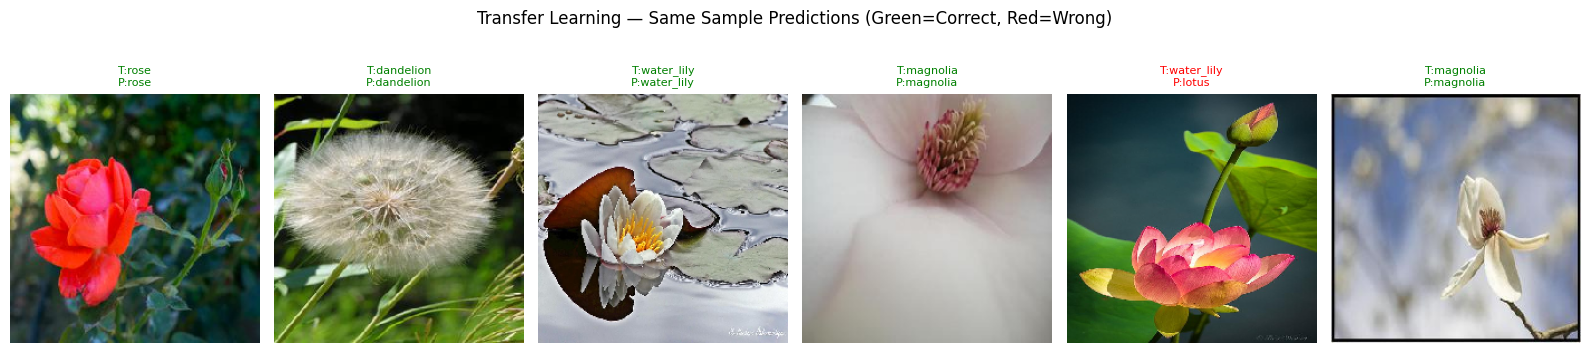

In [43]:
# ── Sample predictions from Transfer Learning model
# Using SAME random images as Baseline & Deeper CNN

x_samples_tl = []
y_trues_tl = []

for idx in random_indices:
    img_path = tl_val.filepaths[idx]

    # Load image at 224x224 for MobileNetV2
    img = tf.keras.utils.load_img(
        img_path,
        target_size=IMG_SIZE_TL
    )

    img_array = tf.keras.utils.img_to_array(img)

    # MobileNetV2 preprocessing
    img_array = mnv2_preprocess(img_array)

    x_samples_tl.append(img_array)
    y_trues_tl.append(tl_val.classes[idx])

# Create batch
x_batch_tl = np.array(x_samples_tl)

# Predict
preds_tl = tl_model.predict(x_batch_tl)

# Plot
fig, axes = plt.subplots(1, 6, figsize=(16,4))

for i, ax in enumerate(axes):

    # Convert image back for display
    display_img = (x_batch_tl[i] + 1) / 2

    ax.imshow(display_img)

    true_label = class_names[y_trues_tl[i]]
    pred_label = class_names[np.argmax(preds_tl[i])]

    color = 'green' if true_label == pred_label else 'red'

    ax.set_title(
        f"T:{true_label}\nP:{pred_label}",
        color=color,
        fontsize=8
    )

    ax.axis('off')

plt.suptitle(
    'Transfer Learning — Same Sample Predictions (Green=Correct, Red=Wrong)'
)

plt.tight_layout()
plt.show()

##Challenges and Observations
#Overfitting

The baseline CNN achieved a validation accuracy of 78.7%, but there was still a gap between training and validation performance, indicating signs of overfitting. To address this, the deeper CNN included Batch Normalization and Dropout layers, which helped improve generalization and increased the validation accuracy to 82.6%. The Transfer Learning model further reduced overfitting and achieved the highest validation accuracy of 90.3%.

#Class Imbalance

The flower dataset was slightly imbalanced, as some flower classes contained more images than others. Classes with larger numbers of samples generally achieved better prediction performance, while minority classes such as orchid, lavender, and lotus were more difficult to classify accurately. This imbalance was reflected in the classification reports and confusion matrices.

#Training Time vs Accuracy Trade-off

The Baseline CNN trained faster but achieved lower accuracy compared to the deeper architectures. The Deeper CNN required more training time due to the increased number of layers and parameters but produced better classification performance. The Transfer Learning model using MobileNetV2 required the longest training time because of fine-tuning, but it achieved the best overall accuracy and most stable predictions.

#Hardware Acceleration

All models were trained using Google Colab with T4 GPU acceleration. GPU support significantly reduced training time and made it possible to efficiently train deeper CNN architectures and transfer learning models. Without GPU acceleration, repeated experimentation and model comparisons would have taken considerably longer.

## ✅ Summary of Results

| Model                            | Key Features                                        | Validation Accuracy |
|----------------------------------|-----------------------------------------------------|---------------------|
| Baseline CNN                     | 3 Conv blocks, 3 Dense layers                       | 78.7%               |
| Deeper CNN                       | 6 Conv layers, Batch Normalization, Dropout         | 82.6%               |
| MobileNetV2 (Transfer Learning)  | Pretrained ImageNet model with fine-tuning          | 90.3%               |

### Key Observations
- I found that using MobileNetV2 for Transfer Learning gave the results with a validation accuracy of 90.3%.

- The Deeper CNN model worked better than the Baseline CNN model because it had convolutional layers that learned more details about the flowers.

- When I used Batch Normalization and Dropout the model became more general. Did not overfit as much.

- The Adam optimizer was really good. It converged faster and gave higher accuracy than the SGD optimizer.

- When I removed Dropout from the model it started to overfit and the validation results were not as stable.

- Even though MobileNetV2 took longer to train it gave the accurate and stable predictions, which is what MobileNetV2 is good, at.

### Conclusion
The MobileNetV2 model was really good at classifying flowers. When we used the weights that MobileNetV2 learned from ImageNet it could find the things to look at in the pictures more easily. This was better than training a model from the beginning. Even though it took longer to train MobileNetV2 this way it was more accurate and better, at figuring out what to do with pictures of flowers.